In [1]:
import numpy as np
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras.layers import Layer
import os
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical

2025-06-11 10:19:11.169469: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-11 10:19:12.214803: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-11 10:19:15.867662: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import feature_engineering_scaling as fes

In [4]:
import RNN_preprocessing_whole as rp

In [5]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649175040, available=1141743616, percent=93.1, used=14965530624, free=202534912, active=937422848, inactive=15100157952, buffers=155189248, cached=1325920256, shared=211005440, slab=247570432)


In [6]:
import gc
gc.collect()

20

In [7]:
print(psutil.virtual_memory()) 

svmem(total=16649175040, available=1132830720, percent=93.2, used=14968520704, free=187174912, active=943976448, inactive=15102889984, buffers=155234304, cached=1338245120, shared=216895488, slab=247525376)


In [8]:
X_seq_test = rp.X_seq_test
y_seq_test = rp.y_seq_test

In [9]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_whole' in sys.modules:
    del sys.modules['RNN_preprocessing_whole']

# Clear memory from global variables if needed
gc.collect()

5

In [10]:
# Load the saved models
model = load_model("../models/model_SimpleRNN_whole.h5")

2025-06-11 10:20:02.872034: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
y_pred = model.predict(X_seq_test) 

40269/40269 [==============================] - 144s 4ms/step


# Functions

In [12]:
def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results

In [13]:
# Min-Max Unscaling Function
def minmax_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the min and max values derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after MinMaxScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    feature_names = ["energy", "r", "z", "phi", "time_diff", "distance"]
    X_scaled = pd.DataFrame(X_scaled, columns=feature_names[:X_scaled.shape[1]])

    min_vals = X_unscaled[columns].min()
    max_vals = X_unscaled[columns].max()
    
    # Formula for unscaling using MinMax: 
    # unscaled_value = scaled_value * (max - min) + min
    X_scaled[columns] = X_scaled[columns] * (max_vals - min_vals) + min_vals
    
    return X_scaled

In [14]:
# Robust Unscaling Function
def robust_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the median and IQR derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after RobustScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    feature_names = ["energy", "r", "z", "phi", "time_diff", "distance"]
    X_scaled = pd.DataFrame(X_scaled, columns=feature_names[:X_scaled.shape[1]])
    median_vals = X_unscaled[columns].median()
    iqr_vals = X_unscaled[columns].quantile(0.75) - X_unscaled[columns].quantile(0.25)
    
    # Formula for unscaling using RobustScaler:
    # unscaled_value = scaled_value * IQR + median
    X_scaled[columns] = X_scaled[columns] * iqr_vals + median_vals
    
    return X_scaled

In [15]:
def plot_event_analysis(X_test, y_pred, y_test, model_name, save_dir, event_types=[1, 2, 4, 5], save_plots=False):
    """
    Plot energy distributions, decay curves, and ROC curve for a given model, and optionally save them.

    Parameters:
        X_test (pandas DataFrame): Feature dataset containing 'r', 'z', and 'time' columns.
        y_pred (numpy array): Predicted event labels (truths).
        model_name (str): Name of the model (used for plot titles and filenames).
        save_dir (str): Path to the directory where plots will be saved.
        event_types (list): List of event types to plot (default includes Bi214, Po214, Bi212, Po212).
        save_plots (bool): Whether to save the plots as PNG files (default is False).
    """
    event_labels = {1: r"$^{214}$Bi", 2: r"$^{214}$Po", 4: r"$^{212}$Bi", 5: r"$^{212}$Po"}

    # Create directory if it doesn't exist
    if save_plots and not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Energy Distribution Plots
    energy_values = X_test.iloc[:, 0]  # Assuming energy is the first column
    
    for event_type in event_types:
        if event_type not in event_labels:  # Skip if event type isn't in the dictionary
            continue
        label = event_labels[event_type]
        plt.figure(figsize=(10, 6))
        
        # Filter energy values for this event type
        event_energy = energy_values[y_pred == event_type]
        
        # Plot histogram
        plt.hist(event_energy, bins=200, alpha=0.7, color="blue", density=False)
        
        # Labels and title
        plt.xlabel("Energy (MeV)")
        plt.ylabel("Number of Events")
        plt.title(f"Energy Distribution of {label} - {model_name}")
        plt.grid(True)
        
        # Save the plot if required
        if save_plots:
            plt.savefig(f"{save_dir}{model_name}_energy_{label}.png")
        
        # Show each plot separately
        plt.show()
    
    # External Background (Class 3) Analysis (r and z)
    r_values = X_test["r"][y_pred == 3]
    z_values = X_test["z"][y_pred == 3]
    
    # Plot r histogram
    plt.figure(figsize=(10, 6))
    plt.hist(r_values, bins=100, alpha=0.6, color="blue", density= False)
    plt.xlabel("r (Radius)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of r for External Background - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_r_external_background.png")
    
    # Show the plot
    plt.show()

    # Plot z histogram
    plt.figure(figsize=(10, 6))
    plt.hist(z_values, bins=100, alpha=0.6, color="red", density=False)
    plt.xlabel("z (Height)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of z for External Background (Class 3) - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_z_external_background.png")
    
    # Show the plot
    plt.show()

    # Find all unique classes in predictions and truth
    all_classes = set(np.unique(np.concatenate((y_pred, y_test))))

    # Ensure 0 and 3 are always mapped to 0
    binary_mapping = {0: 0, 3: 0}

    # Assign 1 to everything in event_types
    for event in event_types:
        binary_mapping[event] = 1

    # Assign 0 to any remaining classes (avoid KeyError)
    for cls in all_classes:
        if cls not in binary_mapping:
            binary_mapping[cls] = 1  # Default to background

    # Convert predictions and truth to binary
    binary_probs = np.array([binary_mapping[label] for label in y_pred])
    binary_truth = np.array([binary_mapping[label] for label in y_test])

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(binary_truth, binary_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend()
    plt.grid()

    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_roc_curve.png")

    # Show the plot
    plt.show()


In [16]:
def calculate_time_differences_for_pair(X_seq_test, label_sequences, event_pair):
    """
    Calculate time differences between a given event pair from sequences.

    Parameters
    ----------
    X_seq_test : np.ndarray
        Array of shape (num_sequences, sequence_length, features). 
        The time information is assumed to be at column index 4.
    label_sequences : np.ndarray
        Array of shape (num_sequences, sequence_length) containing the labels.
    event_pair : tuple
        A tuple (start_event, end_event) specifying the event pair.

    Returns
    -------
    all_diffs : list of lists
        Each inner list contains the time differences for valid (start_event → end_event) pairs in that sequence.
    """
    start_event, end_event = event_pair
    all_diffs = []
    for seq in range(X_seq_test.shape[0]):
        time_diffs = X_seq_test[seq, :, 4]
        labels = label_sequences[seq]
        seq_diffs = []
        i = 0
        while i < len(labels) - 1:
            if labels[i] == start_event and labels[i + 1] == end_event:
                diff = time_diffs[i + 1] - time_diffs[i]
                seq_diffs.append(diff)
                i += 2  # skip the used pair
            else:
                i += 1
        all_diffs.append(seq_diffs)
    return all_diffs

In [17]:
def flatten_differences(diff_lists):
    """
    Flatten a list of lists of time differences into a single list.

    Parameters
    ----------
    diff_lists : list of lists
        Nested list of time differences.

    Returns
    -------
    flattened : list
        A single list containing all time differences.
    """
    return [diff for seq in diff_lists for diff in seq]

In [18]:
def plot_histogram(data, model_name, chain, xlim=None, ylim=None, bins=100, alpha=0.7, save_path=None, zoomed=False):
    """
    Plot a histogram of the data and optionally save it with a specific naming convention.

    Parameters
    ----------
    data : list or array-like
        Data values to plot.
    model_name : str
        The name of the model (e.g., 'BiPo214', 'BiPo212').
    chain : str
        The chain name or description (e.g., 'Parent → Daughter', 'Decay Chain').
    title : str
        Title of the plot.
    xlabel : str
        X-axis label.
    ylabel : str
        Y-axis label.
    xlim : tuple, optional
        Limits for the x-axis (e.g., (0, 0.001)).
    bins : int, optional
        Number of bins in the histogram.
    alpha : float, optional
        Transparency level for the histogram bars.
    save_path : str, optional
        The directory where the plot will be saved. If not provided, the plot will not be saved.
    zoomed : bool, optional
        Whether the plot is zoomed. If True, `_zoomed` will be added to the filename.

    """

    # Default title and labels
    title = f"Decay Curve of {chain} for the {model_name}"
    xlabel = 'Time (seconds)'
    ylabel = 'Number of BiPo Events'

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, alpha=alpha)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
        
    plt.tight_layout()
    
    # Save the plot if a save path is provided
    if save_path:
        # Create the directory if it doesn't exist
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        
        # Generate the filename with the appropriate naming convention
        zoom_suffix = "_zoomed" if zoomed else ""
        filename = f"{model_name}_decay_curve_{chain}{zoom_suffix}.png"
        save_file_path = os.path.join(save_path, filename)
        
        # Save the plot
        plt.savefig(save_file_path)
        print(f"Plot saved to {save_file_path}")
    
    # Display the plot
    plt.show()

In [19]:
#convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=2)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(y_seq_test, axis=2)

In [20]:
# Reshape or flatten the arrays
y_test_classes_flat = y_test_classes.reshape(-1)  # Flatten y_test_classes1
y_pred_classes_flat = y_pred_classes.reshape(-1)  # Flatten y_pred_classes1

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_classes_flat, y_pred_classes_flat)


# Define the folder where you want to save the plot
save_folder = "../plots/SimpleRNN_whole"  # Change this to your desired path

# Full path to save the figure
save_path = os.path.join(save_folder, "confusion_matrix.png")

# Plot and save the confusion matrix
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')  # High-resolution save
plt.close()  # Close the plot to free memory

print(f"Confusion matrix saved to: {save_path}")

Confusion matrix saved to: ../plots/SimpleRNN_whole/confusion_matrix.png


In [23]:
classification = classification_report(y_test_classes_flat, y_pred_classes_flat)
print("Classification Report:\n")
print(classification)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.72      0.82   2156410
           1       0.54      0.39      0.45   2165589
           2       0.92      0.94      0.93   2165969
           3       0.64      0.78      0.70   2154915
           4       0.50      0.64      0.56   2121853
           5       0.92      0.91      0.92   2121314

    accuracy                           0.73  12886050
   macro avg       0.74      0.73      0.73  12886050
weighted avg       0.74      0.73      0.73  12886050



In [24]:
result = signal_detection_metrics(y_test_classes_flat, y_pred_classes_flat, [1, 2, 4, 5])
print(result)


Results for class 1:
  - Total events classified as this class: 1543203
  - Percentage of actual signal events detected: 38.80%
  - Percentage of detected signal accuracy: 54.44%
  - Misclassified as other classes:
    - Class 4: 23.60%
    - Class 3: 9.22%
    - Class 0: 12.73%
    - Class 5: 0.00%
    - Class 2: 0.00%

Results for class 2:
  - Total events classified as this class: 2223417
  - Percentage of actual signal events detected: 94.07%
  - Percentage of detected signal accuracy: 91.64%
  - Misclassified as other classes:
    - Class 5: 6.66%
    - Class 3: 0.43%
    - Class 4: 0.77%
    - Class 0: 0.14%
    - Class 1: 0.36%

Results for class 4:
  - Total events classified as this class: 2693518
  - Percentage of actual signal events detected: 63.93%
  - Percentage of detected signal accuracy: 50.36%
  - Misclassified as other classes:
    - Class 3: 10.25%
    - Class 0: 6.33%
    - Class 1: 31.87%
    - Class 5: 1.15%
    - Class 2: 0.05%

Results for class 5:
  - Total e

In [25]:
X_seq_test_flat = X_seq_test.reshape(-1, 6)

In [26]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax = minmax_unscaler(fes.X, X_seq_test_flat.copy(), columns_minmax)

In [27]:
# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X_test_unscaled_robust = robust_unscaler(fes.X, X_seq_test_flat.copy(), columns_robust)

In [28]:
# Reset the index of each DataFrame
X_test_unscaled_minmax = X_test_unscaled_minmax.reset_index(drop=True)
X_test_unscaled_robust = X_test_unscaled_robust.reset_index(drop=True)
# Define feature names
feature_names = ["energy", "r", "z", "phi", "time_diff", "distance"]
# Convert NumPy array to DataFrame
X_test = pd.DataFrame(X_seq_test_flat, columns=feature_names)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df = pd.concat([
    X_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust[['z']],  # 'z' from Robust unscaled data
    X_test[['phi']],  # Insert 'phi' here
    X_test[['time_diff']],  # 'time' from Robust unscaled data
    X_test[['distance']]
], axis=1)

In [29]:
combined_df.head()

,energy,r,z,phi,time_diff,distance
0,0.873911,1338.825209,-458.273272,-0.772412,0.000000,0.000000
1,2.725277,1564.076992,1055.005996,-0.348106,24.105403,1.591056
2,0.752425,1517.338390,952.825316,-0.377817,24.105671,1.524038
3,1.054034,1371.380061,-378.166073,-0.986262,45.276053,0.603723
4,1.411560,1299.790828,1404.979949,0.317940,88.734387,1.801270


In [30]:
# Set the save directory before the function
save_dir = "../plots/SimpleRNN_whole/"

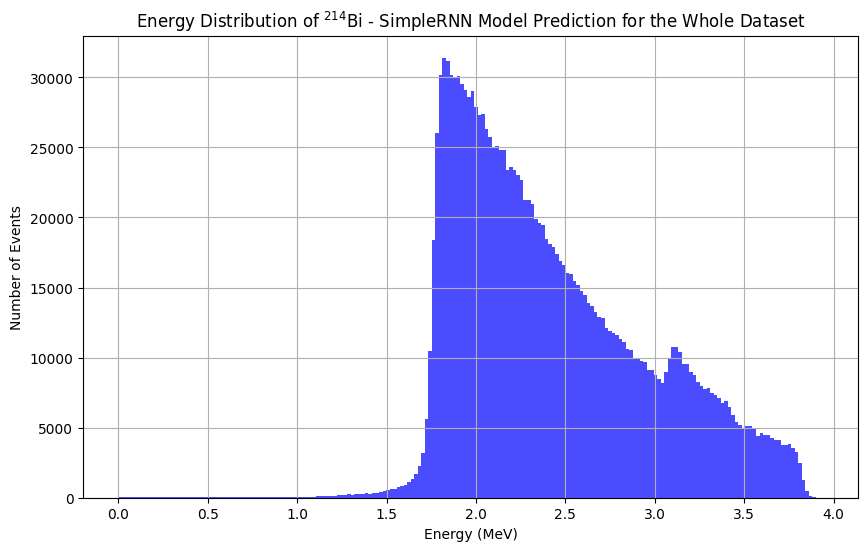

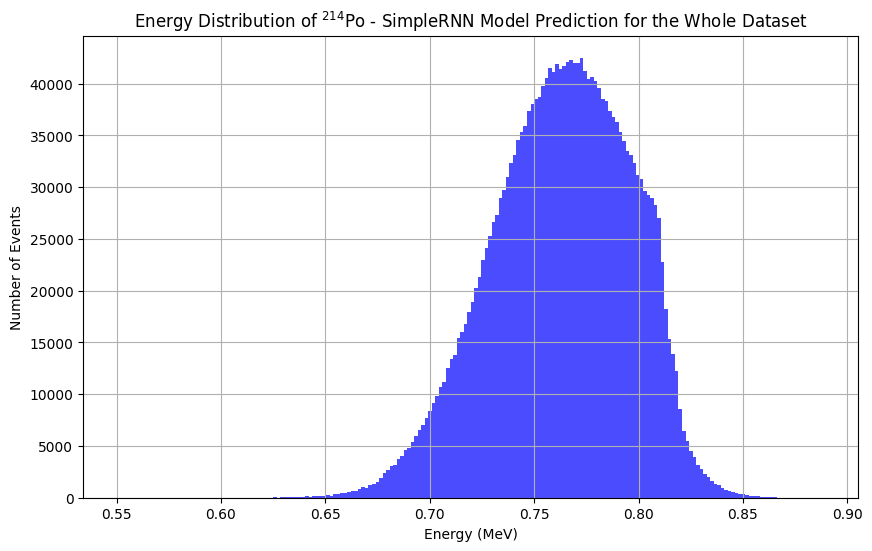

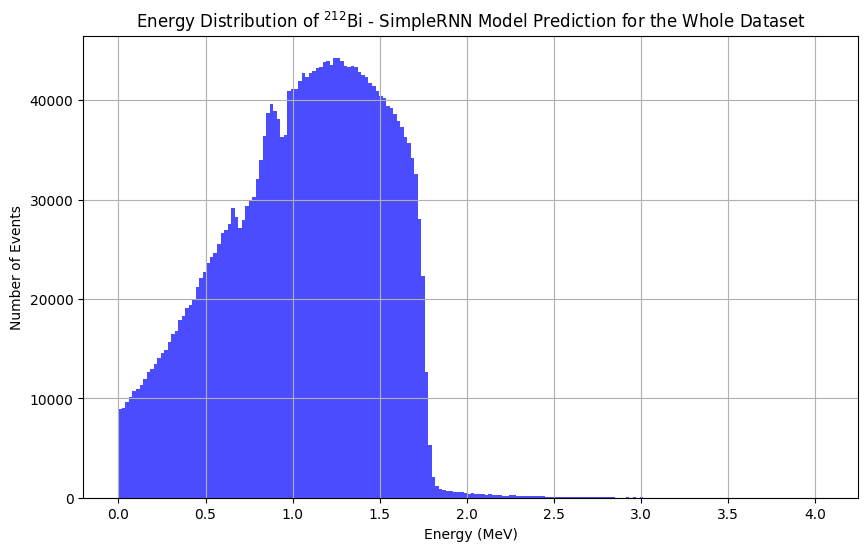

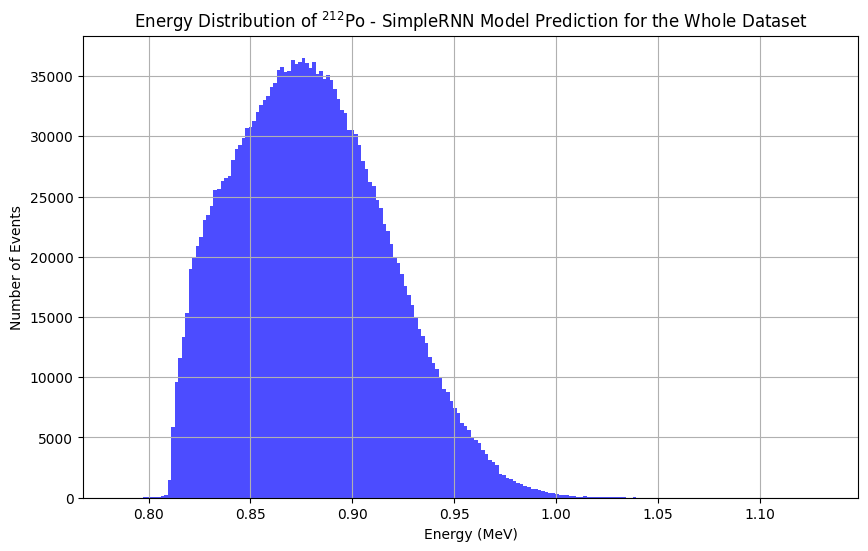

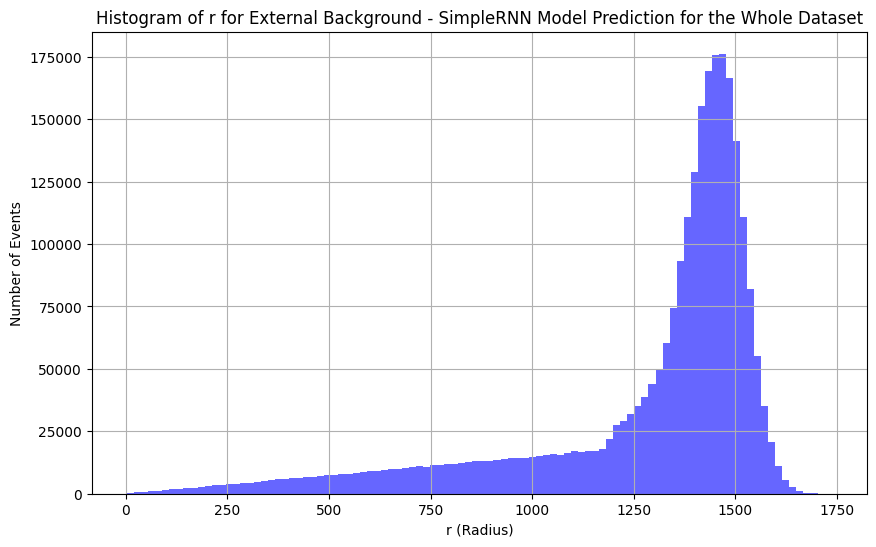

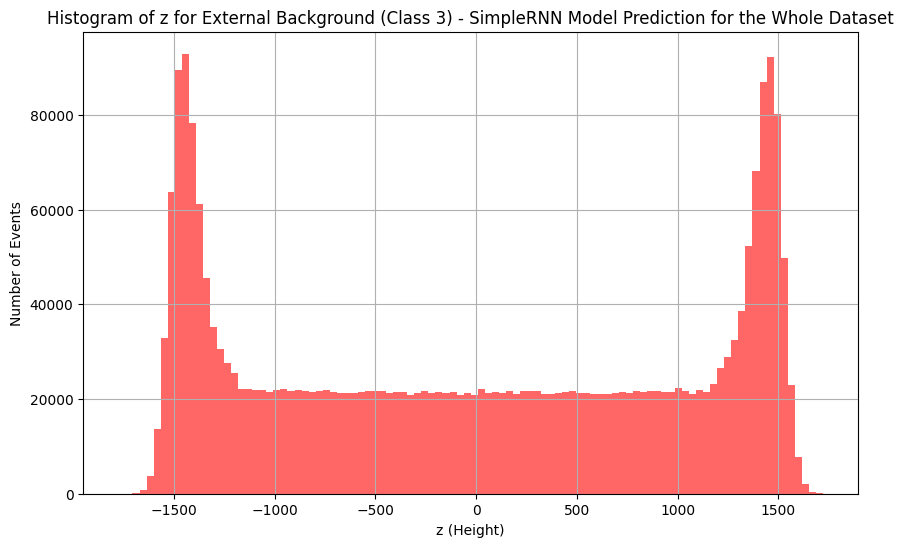

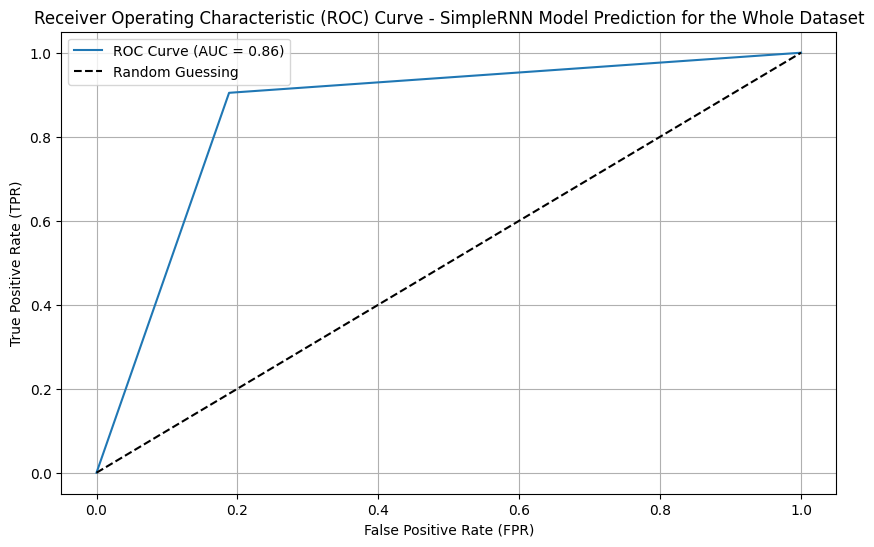

In [31]:
# Call the function and pass save_dir
plot_event_analysis(combined_df, y_pred_classes_flat, y_test_classes_flat, model_name="SimpleRNN Model Prediction for the Whole Dataset", save_dir=save_dir, event_types=[1, 2, 4, 5], save_plots=True)

In [32]:
# For events 1 and 2:
event_pair_1_2 = (1, 2)

# Calculate time differences for predicted sequences (all pairs)
all_result_diffs = calculate_time_differences_for_pair(X_seq_test, y_pred_classes, event_pair_1_2)
flattened_diffs = flatten_differences(all_result_diffs)
# Apply threshold if needed
threshold = 0.01
values_above_threshold = [x for x in flattened_diffs if x > threshold]
print("Predicted values greater than", threshold, ":", values_above_threshold)

# Print the counts
print(len(values_above_threshold))

Predicted values greater than 0.01 : [0.41269880533218384, 0.860161304473877, 0.06558369845151901, 7.794609099626541, 0.9403477013111115, 0.13445640355348587, 0.29269810020923615, 1.0848705023527145, 0.04444769024848938, 0.08197849988937378, 0.8196951895952225, 0.4228737950325012, 0.19051159918308258, 2.614875704050064, 0.05981689691543579, 1.9153386950492859, 0.16938850283622742, 0.5023899003863335, 0.08459089696407318, 0.2041606903076172, 0.14193759858608246, 0.4772518128156662, 0.6725535988807678, 1.0848705023527145, 0.18765540421009064, 1.25626889616251, 0.06417760252952576, 0.4772518128156662, 0.18481170386075974, 1.4245152026414871, 0.8244940042495728, 0.7882537990808487, 2.3966770991683006, 0.6664827987551689, 0.07471950352191925, 0.04041549563407898, 0.4140235036611557, 0.28265000134706497, 0.13445640355348587, 1.042619600892067, 0.860161304473877, 0.349346399307251, 2.118934601545334, 0.31509430706501007, 1.3735604882240295, 0.27818720042705536, 0.20414158701896667, 1.18620239

Plot saved to ../plots/SimpleRNN_whole/SimpleRNN model (Whole Dataset)_decay_curve_$^{214}$BiPo.png


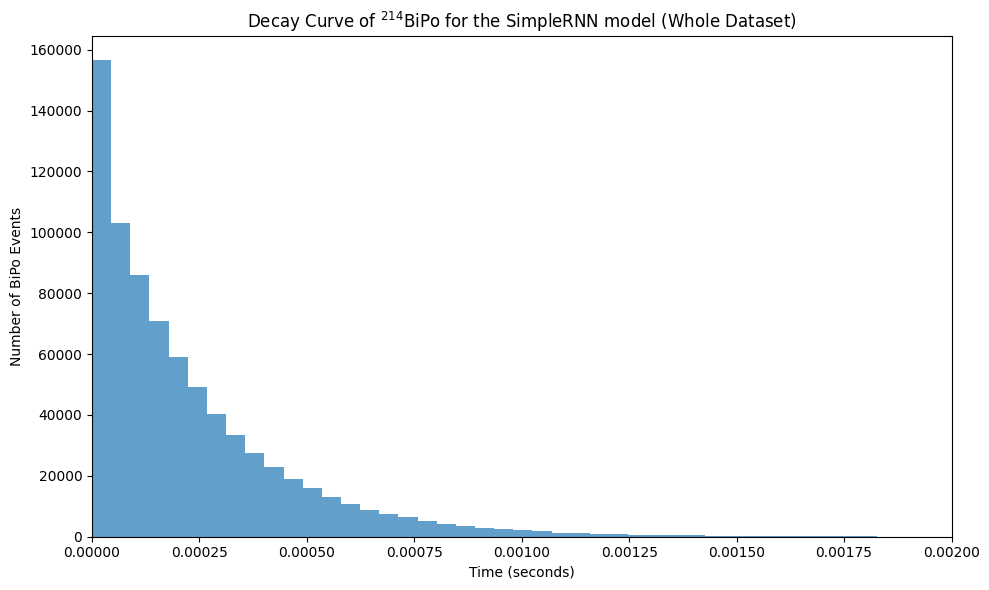

In [33]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero)
filtered_diffs = [x for x in flattened_diffs if x <= threshold and x != 0]
plot_histogram(filtered_diffs,
               model_name= "SimpleRNN model (Whole Dataset)",
               chain= r"$^{214}$BiPo",
               xlim=(0, 0.002),
               save_path=save_folder)

In [34]:
# For events 1 and 2:
event_pair_4_5 = (4, 5)

# Calculate time differences for predicted sequences (all pairs)
all_result_diffs = calculate_time_differences_for_pair(X_seq_test, y_pred_classes, event_pair_4_5)
flattened_diffs = flatten_differences(all_result_diffs)
# Apply threshold if needed
threshold = 0.01
values_above_threshold = [x for x in flattened_diffs if x > threshold]
print("Predicted values greater than", threshold, ":", values_above_threshold)

# Print the counts
print(len(values_above_threshold))

Predicted values greater than 0.01 : [0.8979160934686661, 0.6553158015012741, 0.037706099450588226, 0.14952820539474487, 0.4712824076414108, 0.06326639652252197, 0.014197103679180145, 0.6114997118711472, 0.02841418981552124, 0.10628488659858704, 0.03140439838171005, 0.3234622925519943, 0.40891338884830475, 0.40874840319156647, 0.21461209654808044, 0.35398249328136444, 1.2748951017856598, 0.10610629618167877, 0.512381300330162, 0.2200525999069214, 0.11387999355792999, 0.06233850121498108, 0.11673030257225037, 3.004523992538452, 0.2428574040532112, 0.10777220129966736, 0.40874840319156647, 0.1734434962272644, 0.543103002011776, 1.0033223032951355, 0.36331529915332794, 0.10610629618167877, 0.05252520740032196, 0.12966708838939667, 0.018257401883602142, 0.11387999355792999, 0.5080683082342148, 0.25296449661254883, 0.8948872983455658, 0.2362803965806961, 0.149378702044487, 0.3217909038066864, 0.1734434962272644, 0.36331529915332794, 0.15298350155353546, 0.40891338884830475, 0.54501689970493

Plot saved to ../plots/SimpleRNN_whole/SimpleRNN model (Whole Dataset)_decay_curve_$^{212}$BiPo.png


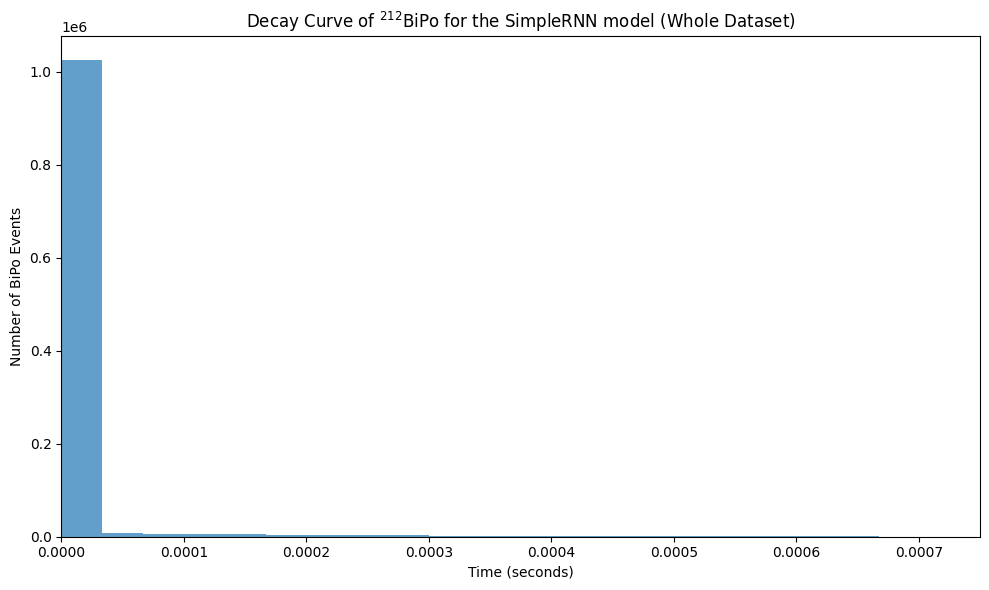

In [35]:
# Plot histogram for predicted differences (filtering to <= threshold and non-zero)
filtered_diffs = [x for x in flattened_diffs if x <= threshold and x != 0]

plot_histogram(filtered_diffs,
               model_name= "SimpleRNN model (Whole Dataset)",
               chain= r"$^{212}$BiPo",
               xlim=(0, 0.00075),
               save_path=save_folder)

Plot saved to ../plots/SimpleRNN_whole/SimpleRNN model (Whole Dataset)_decay_curve_$^{212}$BiPo_zoomed.png


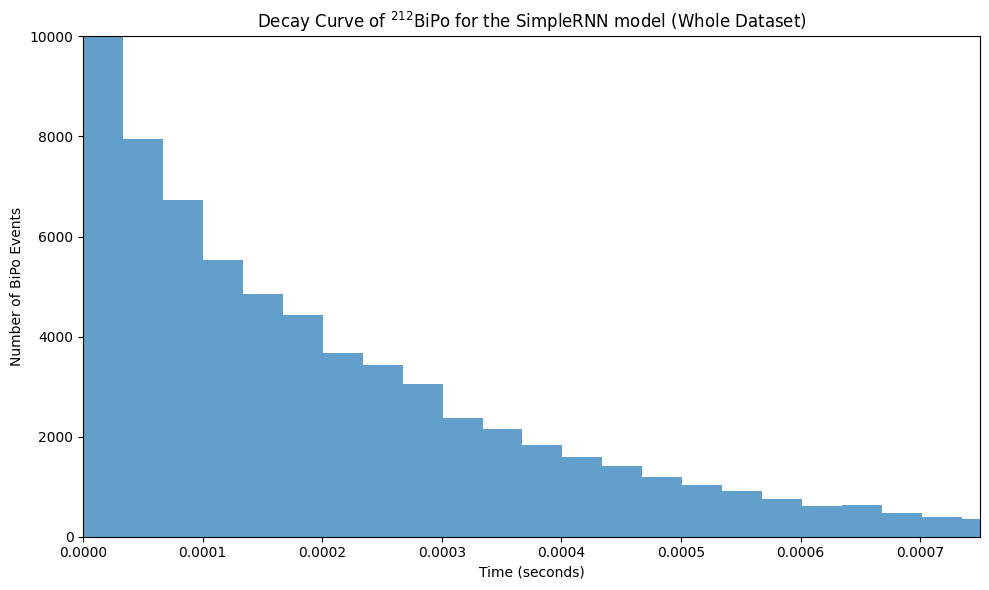

In [36]:
plot_histogram(filtered_diffs,
               model_name= "SimpleRNN model (Whole Dataset)",
               chain= r"$^{212}$BiPo",
               xlim=(0, 0.00075),
               ylim=(0,1e4),
               save_path=save_folder,
               zoomed=True)